## Install library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

## Membaca Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# ganti dengan nama file kamu
df = pd.read_csv("supply_chain_logistic.csv", sep=';')

df.head()

,latitude,longitude,penggunaan_bbm,tingkat_kemacetan,risiko_pengiriman
0,40.375.568.475.194.900,-770.143.177.425.258,5.136.511.864.928.780,5.927.585.801.443.970,11.821.159.890.280.700
1,3.350.781.833.905.290,-11.703.690.240.506.400,5.101.511.530.652.880,15.919.921.912.280.300,961.198.830.435.769
2,30.020.639.789.030.900,-752.692.240.366.282,5.090.802.620.415.410,8.787.765.349.367.670,6.570.431.288.350.110
3,36.649.222.512.758.900,-7.019.052.930.366.370,8.219.557.503.166.250,0.04525714813036494,0.5489520412771786
4,30.001.279.284.395.600,-7.001.219.476.429.300,5.000.074.881.555.600,8.004.850.904.938.760,8.861.442.874.133.280


## Mengubah tipe data longitude dan latitude menjadi string

In [ ]:
df['latitude'] = df['latitude'].str.replace('.', '', regex=False)
df['longitude'] = df['longitude'].str.replace('.', '', regex=False)

df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

## Normalisasi data dengan membagi kolom latitude dan longitude dengan 10^15

In [ ]:
df['latitude'] = df['latitude'] / 1e15
df['longitude'] = df['longitude'] / 1e15

df[['latitude','longitude']].describe()

,latitude,longitude
count,32065.000000,32065.000000
mean,16.367940,-7.846881
std,16.413666,3.281024
min,0.000333,-12.000000
25%,3.503354,-10.307297
50%,4.714683,-8.063714
75%,30.979284,-7.055771
max,50.000000,-0.000703


In [ ]:
df.head()

,latitude,longitude,penggunaan_bbm,tingkat_kemacetan,risiko_pengiriman
0,40.375568,-0.770143,5.136.511.864.928.780,5.927.585.801.443.970,11.821.159.890.280.700
1,3.350782,-11.703690,5.101.511.530.652.880,15.919.921.912.280.300,961.198.830.435.769
2,30.020640,-0.752692,5.090.802.620.415.410,8.787.765.349.367.670,6.570.431.288.350.110
3,36.649223,-7.019053,8.219.557.503.166.250,0.04525714813036494,0.5489520412771786
4,30.001279,-7.001219,5.000.074.881.555.600,8.004.850.904.938.760,8.861.442.874.133.280


## Memilih data random dengan ukuran entri tertentu n=15, untuk mempersingkat komputasi

In [ ]:
df = df.sample(n=15, random_state=42).reset_index(drop=True)

## Scaling kolom yang memiliki nilai yang tidak normal

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_scale = [
    'penggunaan_bbm',
    'tingkat_kemacetan',
    'risiko_pengiriman'
]

#Data cleaning, menghapus adanya titik dan convert tipe data menjadi numerik
for col in columns_to_scale:
    #Menghilangkan titik
    df[col] = df[col].astype(str).str.replace('.', '', regex=False)
    #Mengubah menjadi data numerik
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

df.head()

,latitude,longitude,penggunaan_bbm,tingkat_kemacetan,risiko_pengiriman
0,4.750485,-7.484776,0.270829,0.000000,0.136621
1,31.533646,-7.324354,0.182163,1.000000,0.144313
2,30.002357,-7.046873,0.073656,0.353846,1.000000
3,4.999279,-11.518510,0.169098,0.118864,0.147782
4,30.002796,-0.816313,0.180200,0.062535,0.356139


## Menghitung jarak antara setiap titik lokasi yang ada di dalam dataset dan menyimpan ke dalam sebuah matriks

In [ ]:
import numpy as np
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # rata-rata jari-jari bumi
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

n = len(df)
distance_matrix = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        if i != j:
            distance_matrix[i][j] = haversine(
                df.loc[i,'latitude'], df.loc[i,'longitude'],
                df.loc[j,'latitude'], df.loc[j,'longitude']
            )

In [ ]:
cost_distance = distance_matrix.copy()

In [ ]:
cost_optimized = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        if i != j:
            cost_optimized[i][j] = (
                0.4 * distance_matrix[i][j] +
                0.3 * df.loc[j,'penggunaan_bbm']*100 +
                0.2 * df.loc[j,'tingkat_kemacetan']*100 +
                0.1 * df.loc[j,'risiko_pengiriman']*100
            )

In [ ]:
def solve_tsp(cost_matrix):
    n = len(cost_matrix)
    visited = [False]*n
    route = [0]
    visited[0] = True

    for _ in range(n-1):
        last = route[-1]
        next_city = min(
            [(cost_matrix[last][j], j) for j in range(n) if not visited[j]]
        )[1]
        route.append(next_city)
        visited[next_city] = True

    route.append(0)  # kembali ke awal
    return route

## Melihat path yang dipilih program

In [ ]:
tsp_distance = solve_tsp(cost_distance)
tsp_optimized = solve_tsp(cost_optimized)

print("Route Distance:", tsp_distance)
print("Route Optimized:", tsp_optimized)

Route Distance: [0, 8, 10, 13, 3, 7, 9, 11, 4, 2, 5, 6, 12, 1, 14, 0]
Route Optimized: [0, 8, 13, 3, 10, 7, 9, 11, 4, 5, 2, 6, 12, 1, 14, 0]


In [ ]:
import matplotlib.pyplot as plt

def plot_route_with_order(route, title):
    plt.figure()

    lats = df['latitude']
    lons = df['longitude']

    # plot semua titik
    plt.scatter(lons, lats)

    # tandai titik start (hijau)
    plt.scatter(df.loc[route[0],'longitude'],
                df.loc[route[0],'latitude'],
                s=150)

    # gambar garis + panah
    for i in range(len(route)-1):
        x1 = df.loc[route[i],'longitude']
        y1 = df.loc[route[i],'latitude']
        x2 = df.loc[route[i+1],'longitude']
        y2 = df.loc[route[i+1],'latitude']

        plt.arrow(x1, y1, x2-x1, y2-y1,
                  length_includes_head=True,
                  head_width=0.3)

    # tambahkan nomor urutan kunjungan
    for idx, node in enumerate(route):
        plt.text(df.loc[node,'longitude'],
                 df.loc[node,'latitude'],
                 str(idx),
                 fontsize=12)

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()

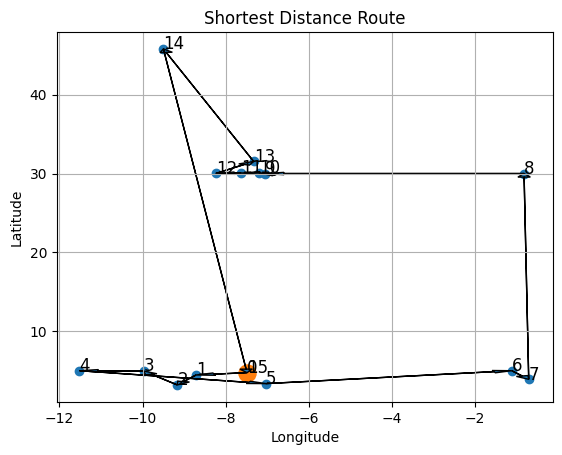

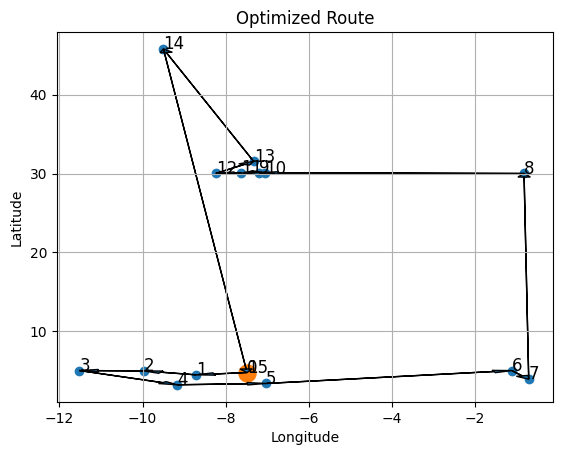

In [ ]:
plot_route_with_order(tsp_distance, "Shortest Distance Route")
plot_route_with_order(tsp_optimized, "Optimized Route")

In [ ]:
def hitung_total(route, df, distance_matrix):
    total_distance = 0
    total_bbm = 0
    total_kemacetan = 0
    total_risiko = 0

    for i in range(len(route)-1):
        from_node = route[i]
        to_node = route[i+1]

        # total jarak
        total_distance += distance_matrix[from_node][to_node]

        # atribut tujuan
        total_bbm += df.loc[to_node,'penggunaan_bbm']
        total_kemacetan += df.loc[to_node,'tingkat_kemacetan']
        total_risiko += df.loc[to_node,'risiko_pengiriman']

    return total_distance, total_bbm, total_kemacetan, total_risiko

In [ ]:
dist_d, bbm_d, macet_d, risiko_d = hitung_total(tsp_distance, df, distance_matrix)

dist_o, bbm_o, macet_o, risiko_o = hitung_total(tsp_optimized, df, distance_matrix)

## Summary Hasil Optimasi

In [ ]:
print("===== SHORTEST DISTANCE =====")
print(f"Total Jarak (km)      : {dist_d:.2f}")
print(f"Total BBM             : {bbm_d:.2f}")
print(f"Total Kemacetan       : {macet_d:.2f}")
print(f"Total Risiko          : {risiko_d:.2f}")

print("\n===== OPTIMIZED ROUTE =====")
print(f"Total Jarak (km)      : {dist_o:.2f}")
print(f"Total BBM             : {bbm_o:.2f}")
print(f"Total Kemacetan       : {macet_o:.2f}")
print(f"Total Risiko          : {risiko_o:.2f}")

===== SHORTEST DISTANCE =====
Total Jarak (km)      : 11993.17
Total BBM             : 2.79
Total Kemacetan       : 3.07
Total Risiko          : 3.60

===== OPTIMIZED ROUTE =====
Total Jarak (km)      : 11843.16
Total BBM             : 2.79
Total Kemacetan       : 3.07
Total Risiko          : 3.60
